In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Load the dataset


In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


id: Unique identifier for each transaction.
V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.).
Amount: The transaction amount.
Class: Binary label indicating whether the transaction is fraudulent (1) or not (0).


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Exploratory Data Analysis (EDA)


In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

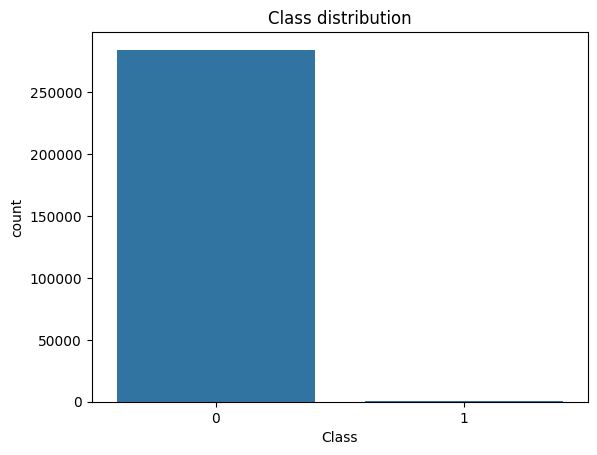

In [7]:
sns.countplot(x='Class', data=df)
plt.title("Class distribution")
plt.show()

In [8]:
# % of frauds to the total data

(df["Class"].value_counts()[1] / df.shape[0]) * 100

np.float64(0.1727485630620034)

In [9]:
# check missing values

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

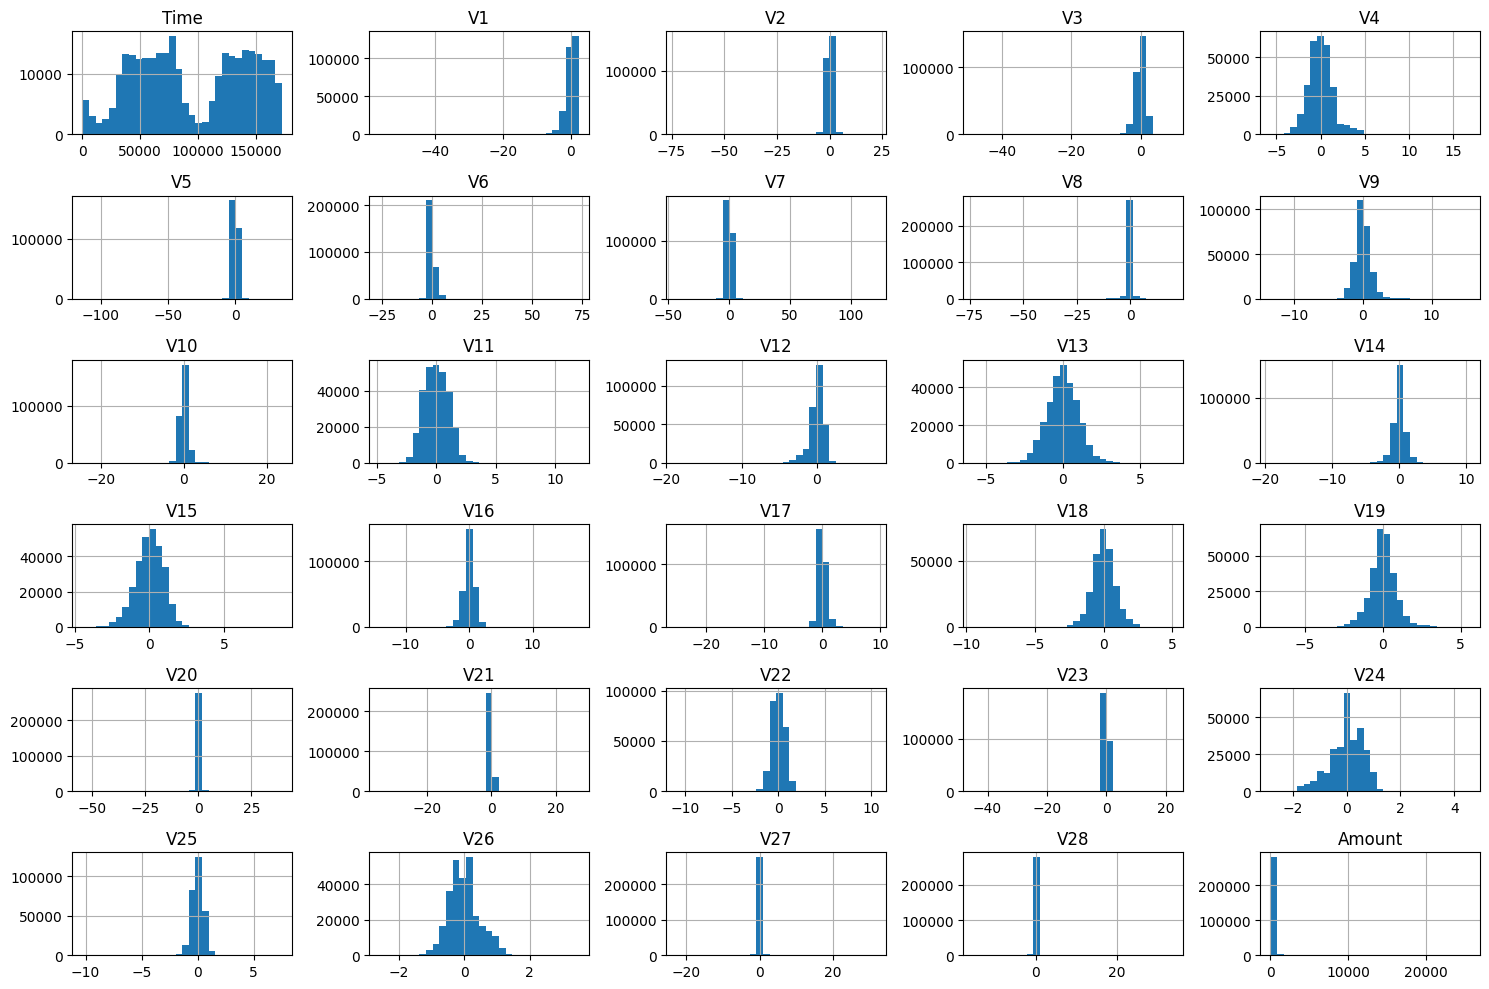

In [10]:
# Distribution of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Class')
df[numeric_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()


In [11]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Text(0.5, 1.0, 'Amount Distribution (log scale)')

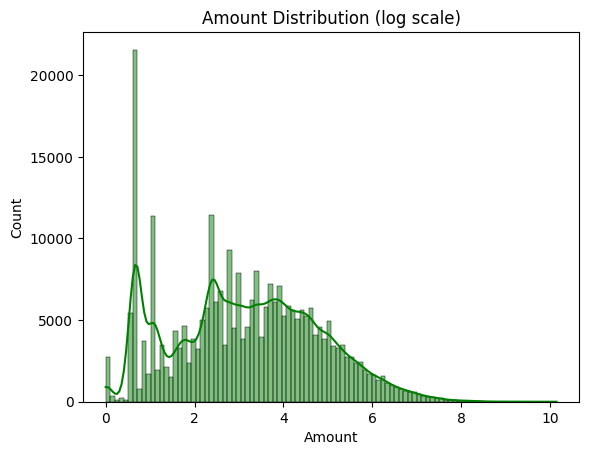

In [12]:
sns.histplot(np.log1p(df["Amount"]), bins = 100, kde = True, color= "green")
plt.title("Amount Distribution (log scale)")

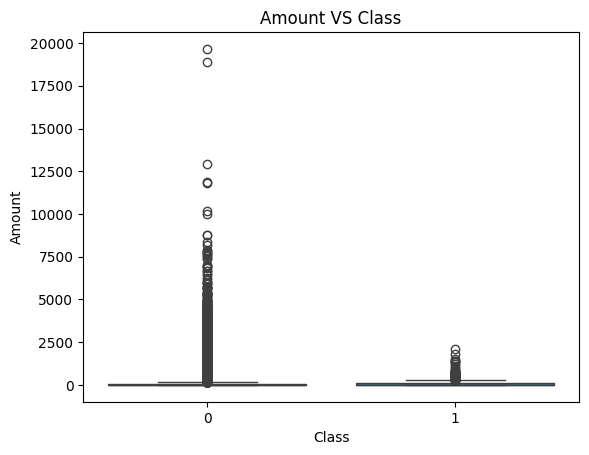

In [13]:
sns.boxplot(data= df[df["Amount"] < 25000], x = "Class", y = "Amount")
plt.title("Amount VS Class")
plt.show()

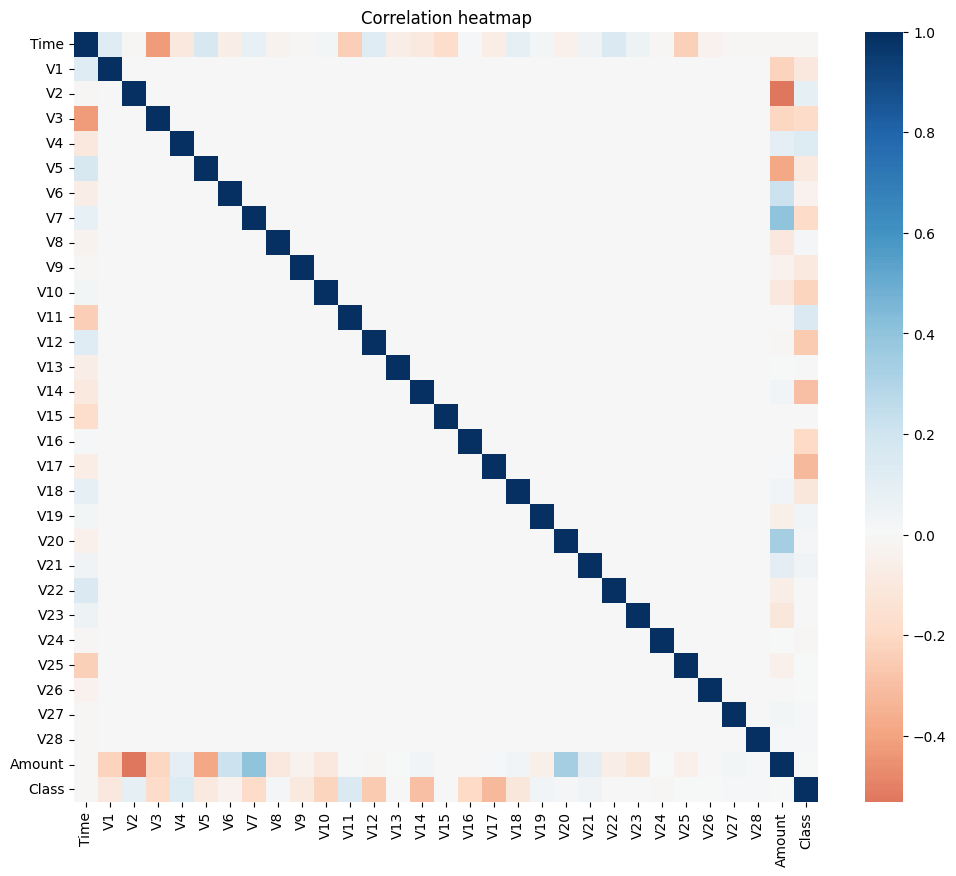

In [14]:
# Correlation heatmap

plt.figure(figsize = (12,10))
sns.heatmap(df.corr(), cmap="RdBu", center = 0)
plt.title("Correlation heatmap")
plt.show()

Data Cleaning


In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
# check for dupicates
df.duplicated().sum()

np.int64(1081)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(283726, 31)

Preprocessing for modelling


In [20]:
#Split features and target

X = df.drop(columns=['Class'])
y = df['Class']

In [21]:
#Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train set:", X_train.shape, y_train.value_counts())
print("Test set:", X_test.shape, y_test.value_counts())

Train set: (226980, 30) Class
0    226602
1       378
Name: count, dtype: int64
Test set: (56746, 30) Class
0    56651
1       95
Name: count, dtype: int64


In [22]:
#Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
#Handle class imbalance

# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# print(y_train_res.value_counts())

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

In [25]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [26]:

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights
)
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_test_scaled)

Accuracy : 99.95%
recall : 0.71
precision : 0.97
f1 : 0.82


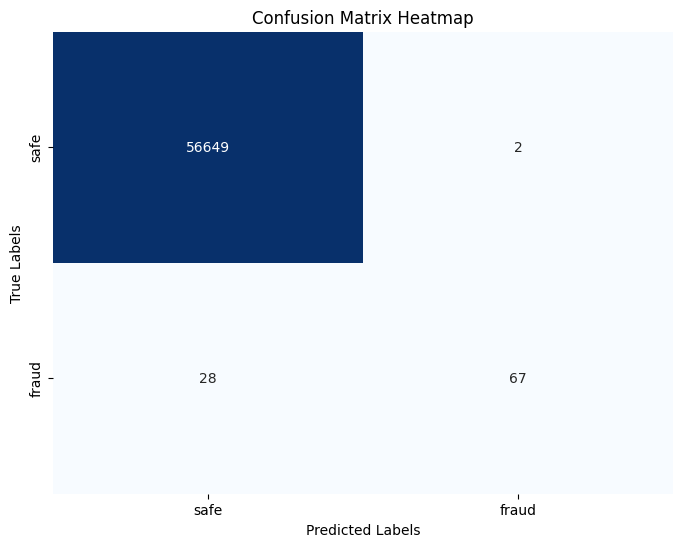

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy * 100:.2f}%')
print(f'recall : {recall:.2f}')
print(f'precision : {precision:.2f}')
print(f'f1 : {f1:.2f}')

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=("safe", "fraud"), yticklabels=("safe", "fraud"))

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [28]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


fraud_ratio = y_train.mean()

iso = IsolationForest(
    contamination = fraud_ratio,
    n_estimators=200,
    random_state=42
)

iso.fit(X_train_scaled)

y_pred_test = iso.predict(X_test_scaled)

y_pred_test = [1 if p == -1 else 0 for p in y_pred_test]

# Scores for ROC-AUC
scores_test = -iso.decision_function(X_test_scaled)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, scores_test))

Confusion Matrix:
 [[56580    71]
 [   77    18]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.20      0.19      0.20        95

    accuracy                           1.00     56746
   macro avg       0.60      0.59      0.60     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9304496877929409


In [30]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # imbalance ratio
clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

In [31]:
clf.fit(X_train_scaled, y_train)
y_prob = clf.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

c:\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:34:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
 [[56649     2]
 [   28    67]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9744916473811491


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ============================
# Convert X to Torch Tensors
# ============================
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_scaled, dtype=torch.float32)

# Fix y_train indexing issue
y_train_np = np.array(y_train)

# Keep only normal samples for training (fraud = 1, normal = 0)
X_train_normal = X_train_torch[y_train_np == 0]

input_dim = X_train_scaled.shape[1]


# ============================
# Autoencoder Model Definition
# ============================
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ============================
# Train Autoencoder
# ============================
epochs = 25
for epoch in range(epochs):
    model.train()
    output = model(X_train_normal)
    loss = criterion(output, X_train_normal)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss: {loss.item():.6f}")


# ============================
# Reconstruction Errors (Train)
# ============================
model.eval()
with torch.no_grad():
    recon_train = model(X_train_normal)
    train_errors = torch.mean((X_train_normal - recon_train)**2, dim=1).numpy()

# Select threshold from training errors (95th percentile)
threshold = np.percentile(train_errors, 95)
print("Chosen Threshold:", threshold)


# ============================
# Reconstruction Errors (Test)
# ============================
with torch.no_grad():
    recon_test = model(X_test_torch)
    test_errors = torch.mean((X_test_torch - recon_test)**2, dim=1).numpy()

# Predict frauds
y_pred_auto = (test_errors > threshold).astype(int)


# ============================
# Evaluation
# ============================
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_auto))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_auto))

print("ROC-AUC:", roc_auc_score(y_test, test_errors))


Epoch 0/25 - Loss: 0.986633
Epoch 5/25 - Loss: 0.982534
Epoch 10/25 - Loss: 0.978806
Epoch 15/25 - Loss: 0.975265
Epoch 20/25 - Loss: 0.971761
Chosen Threshold: 1.9271548

Confusion Matrix:
[[53790  2861]
 [   17    78]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.82      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.89      0.51     56746
weighted avg       1.00      0.95      0.97     56746

ROC-AUC: 0.9384833639764802
